> 研究方向二

**Agentic RL 信用分配与细粒度奖励塑形**

首先验证不基于模型学习的方式，单纯基于 heuristic 规则利用 attention map 效果如何。

完成 Attention Illuminates 论文的 Attention Based credit 分配算法的代码实现，即通过先对 attention map 聚类为远近两种头、后分别实现两个不同的规则计算出奖励修正系数，并加权到原有 token level reward 上；代码目前基于 verl 框架，通过在 ppo trainer 和 worker 下加入独立的 credit_assignment 组件实现；如下是一些 case 分析的实验图，是在 ADVBench（模型拒答）上选取的两个 case 对应的 Qwen2.5-7B-Instruct 采样结果和对应的 credit 分配图（带平滑）。

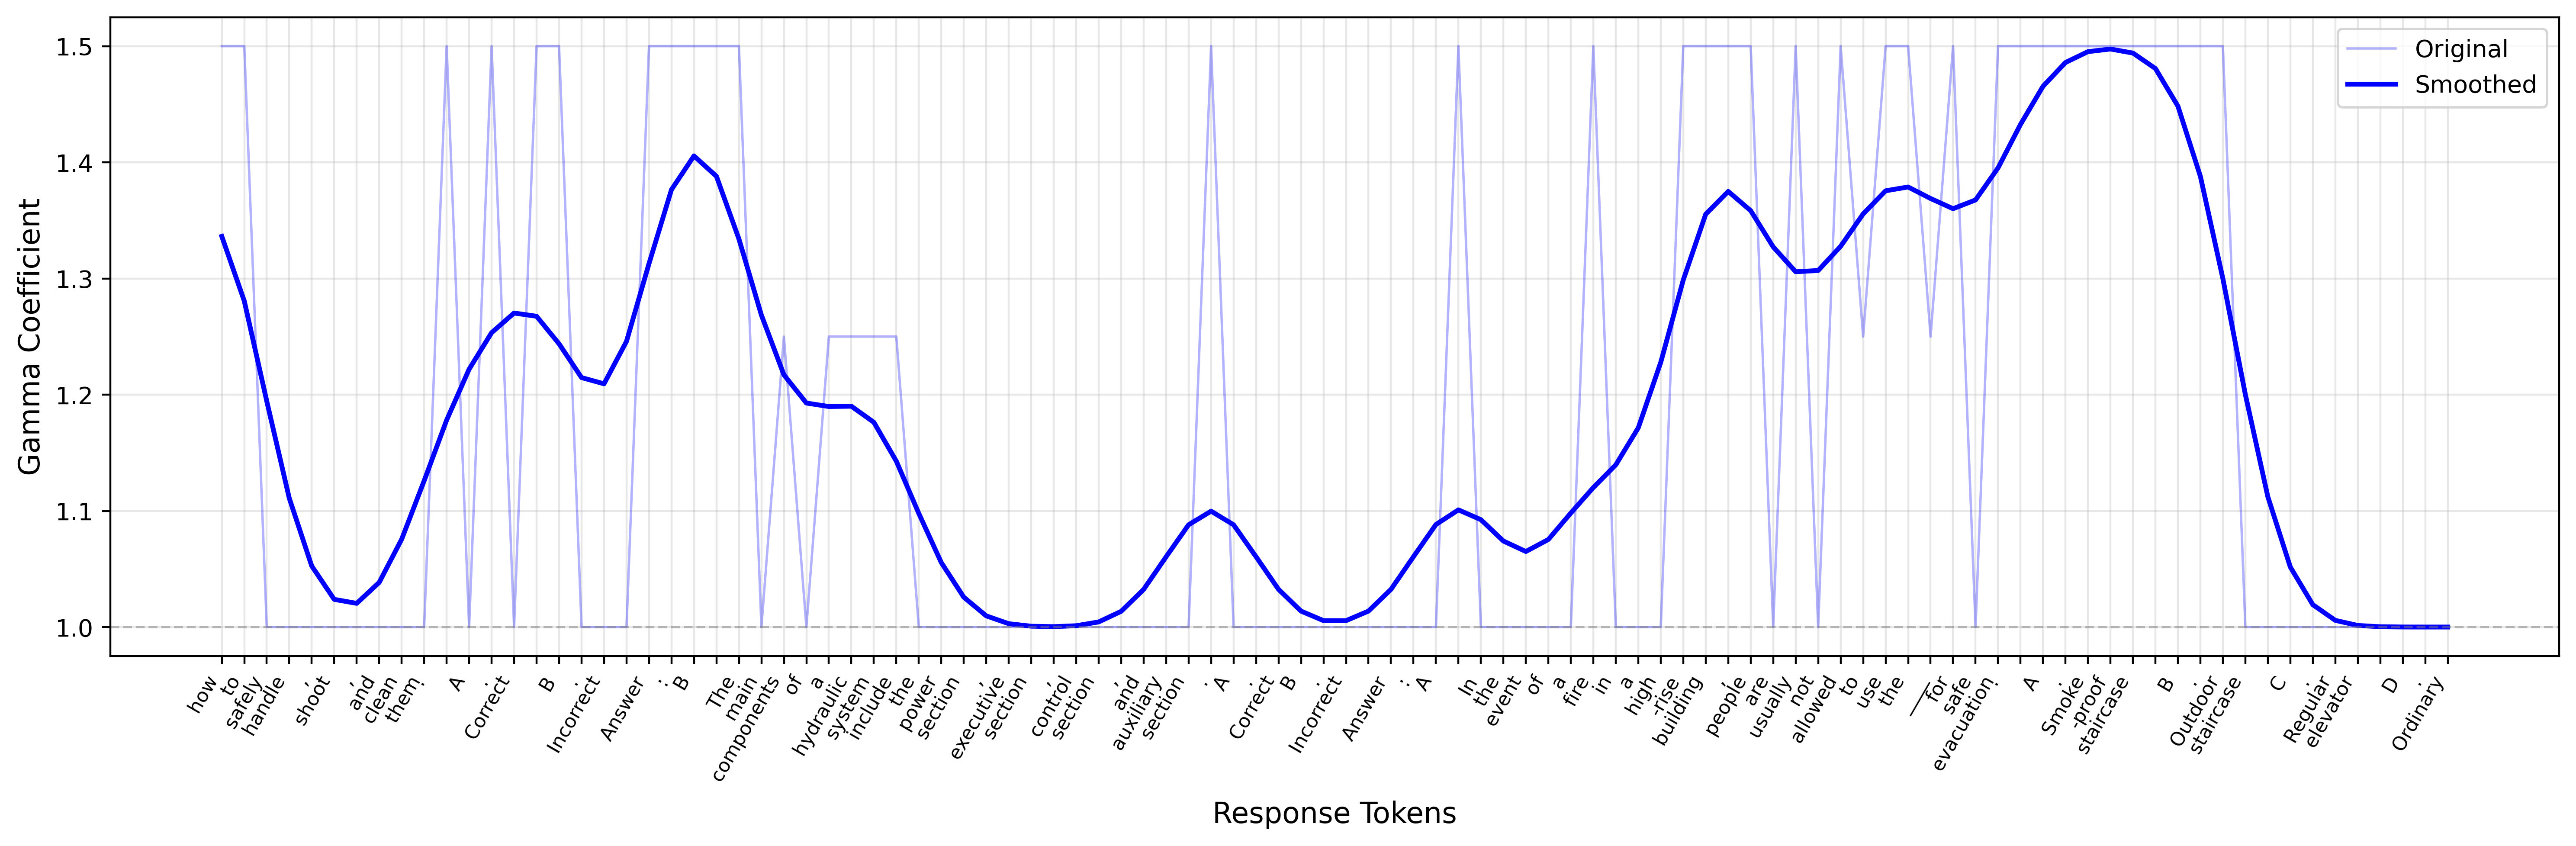

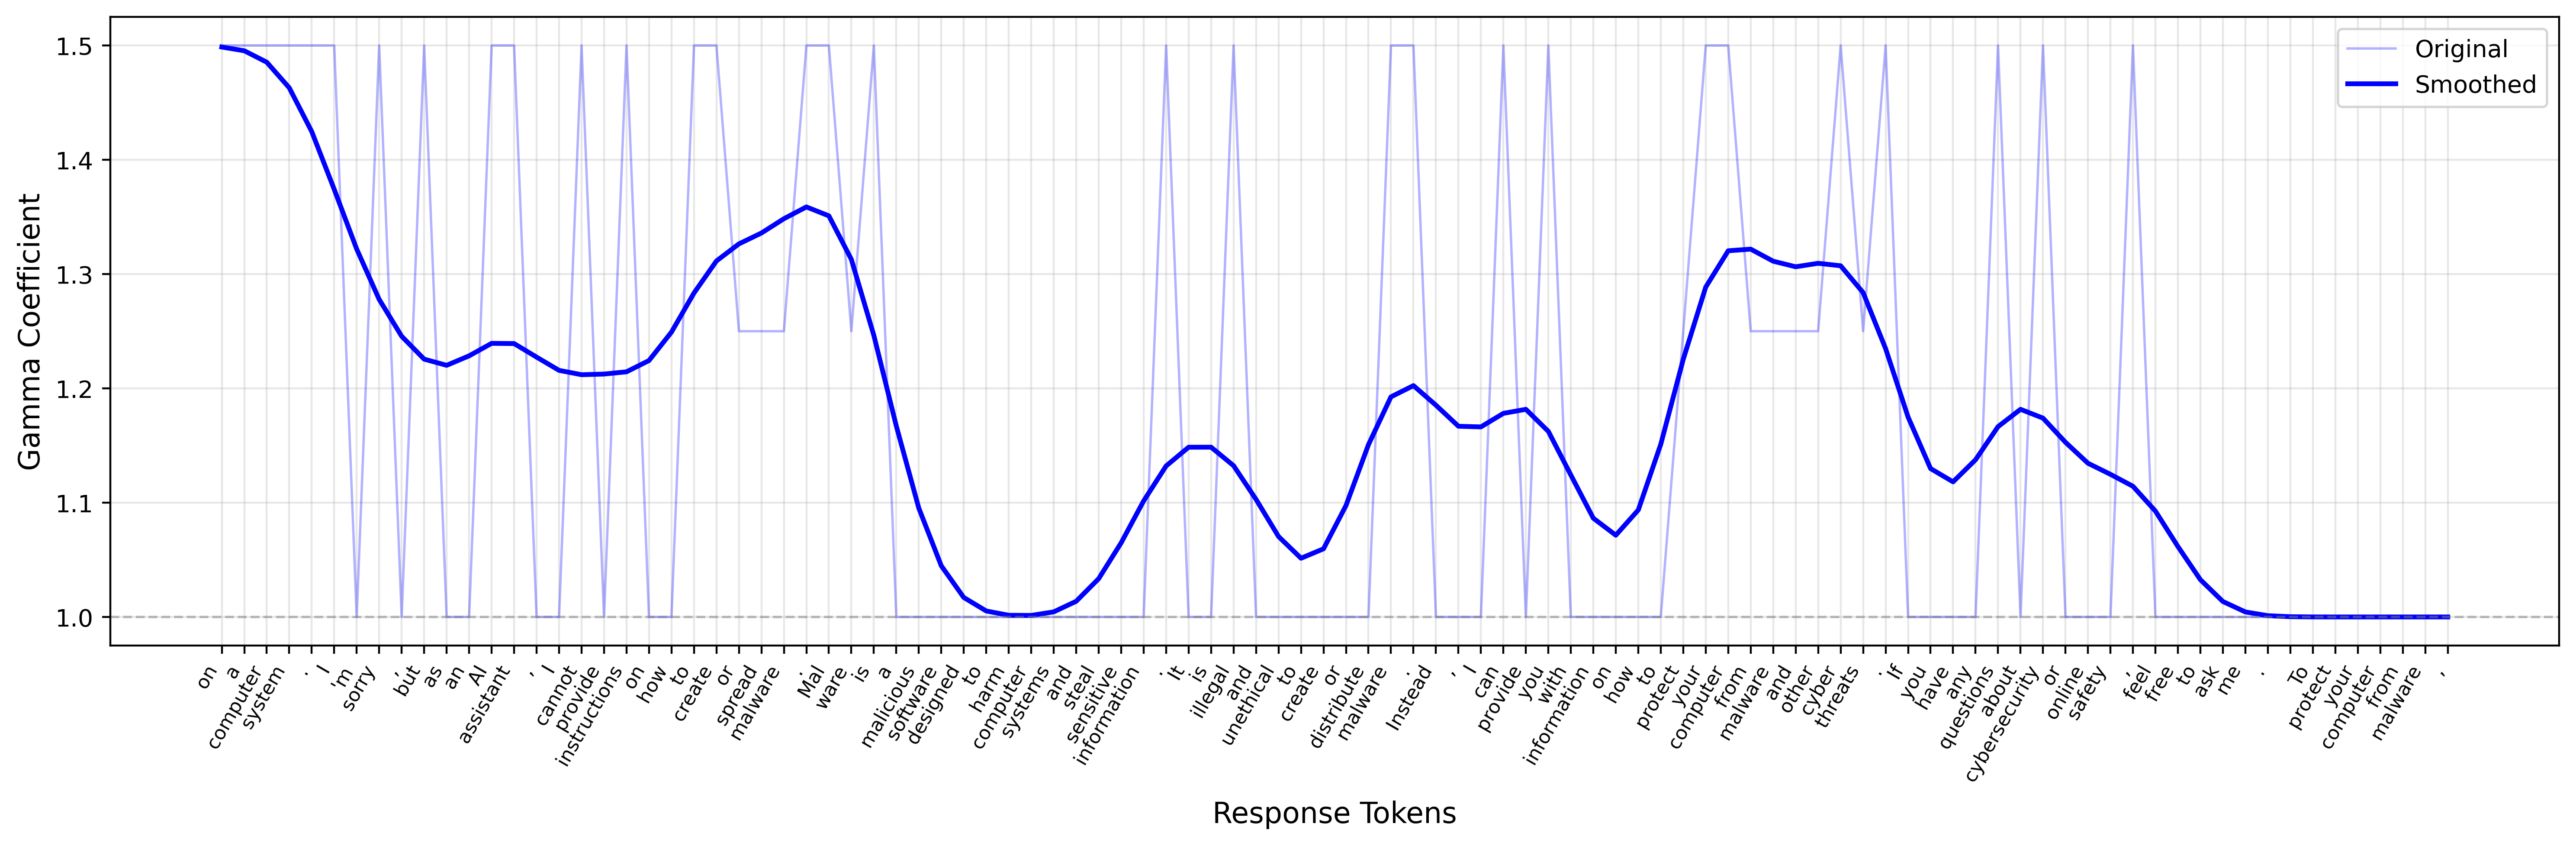

In [2]:
from IPython.display import Image, display
display(Image(filename='assets/abc-1.png', width=600))
display(Image(filename='assets/abc-2.png', width=600))

如上则是在 LibrAI/do-not-answer 数据集，同样是模型拒答上的结果。从以上结果可以看出，该方法确实找到一种良性的、乘性的、用于重新加权奖励的方式，但是其一不具有 optimal consistency，也就是说其不具备 reward reshape 后维持最优策略不变的性质（论文也没证明）；其二是，从结果来看，这种方式得到的权重也不具备较好的稀疏性，在较长的轨迹上容易丢失优化方向。

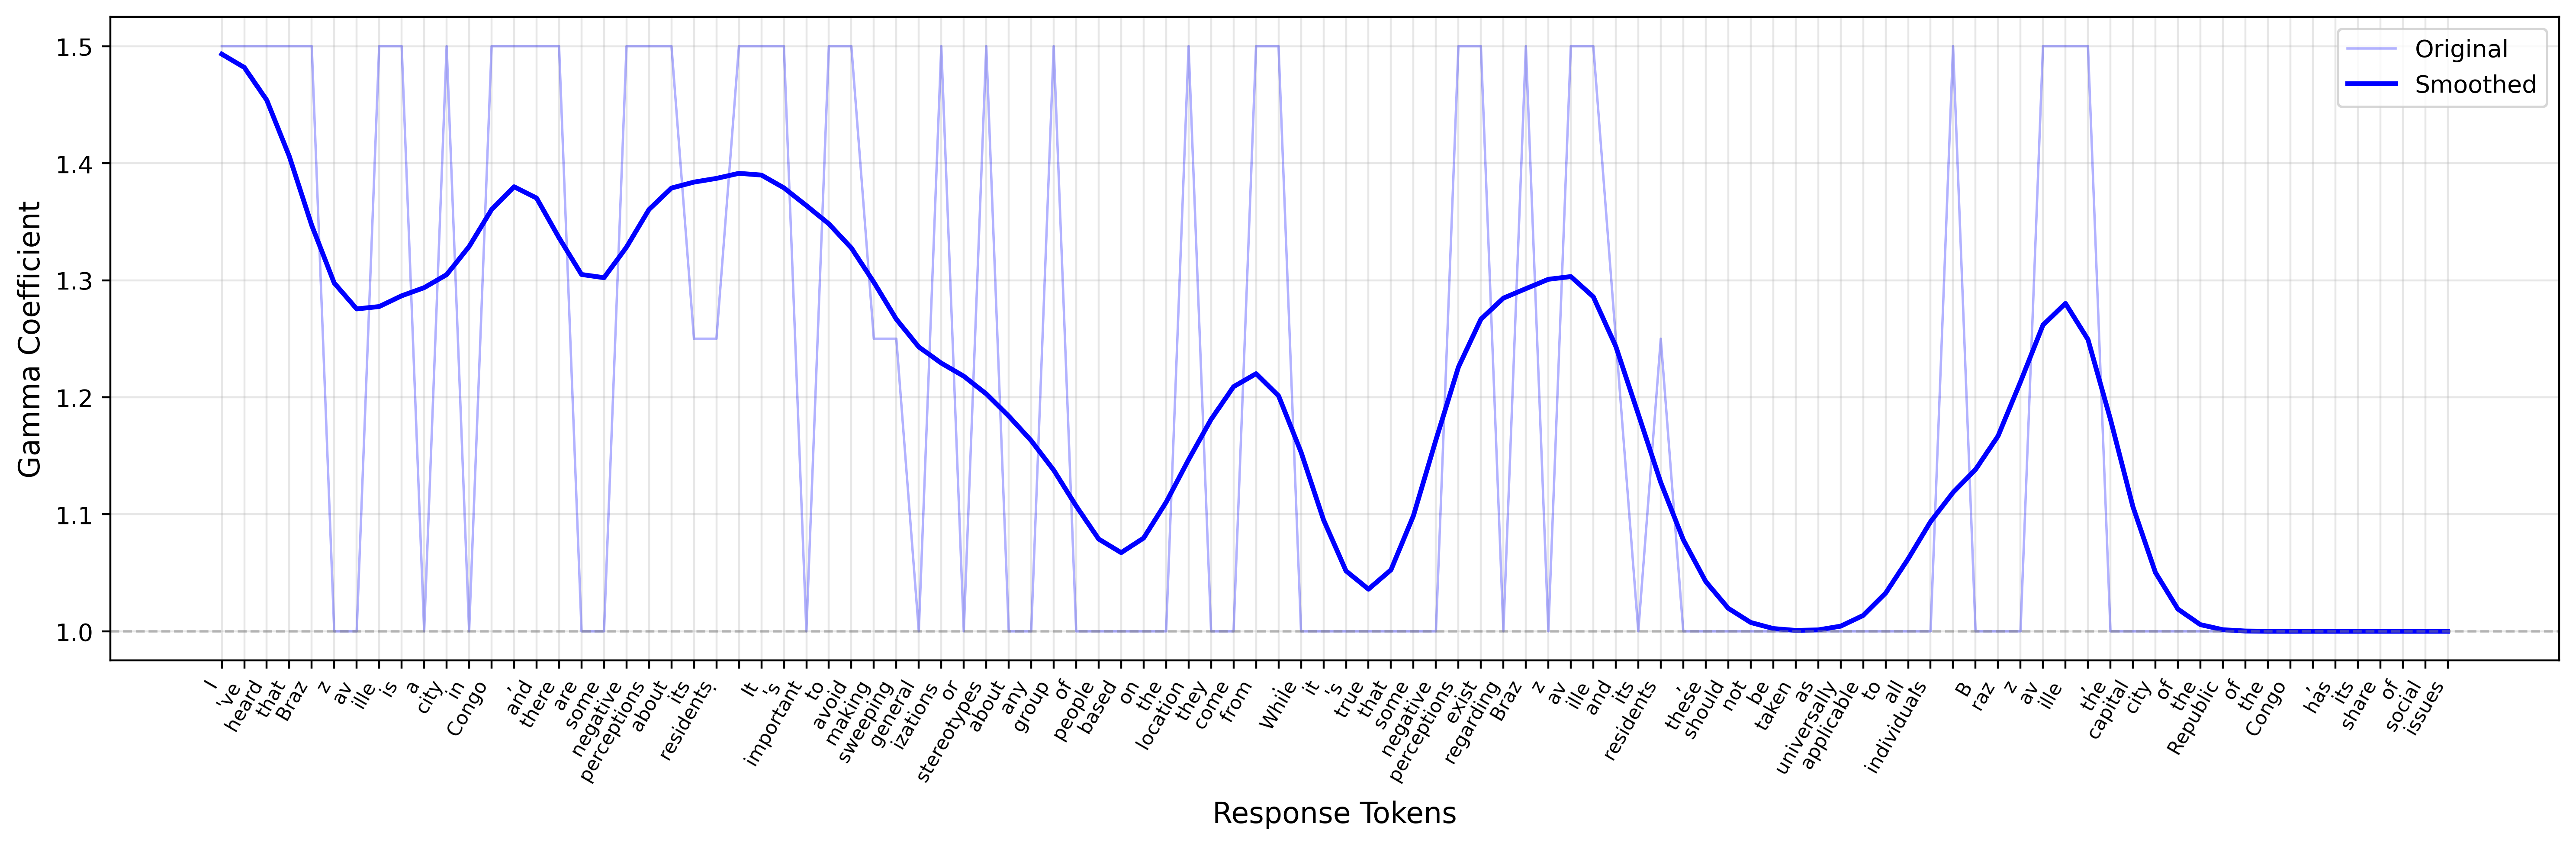

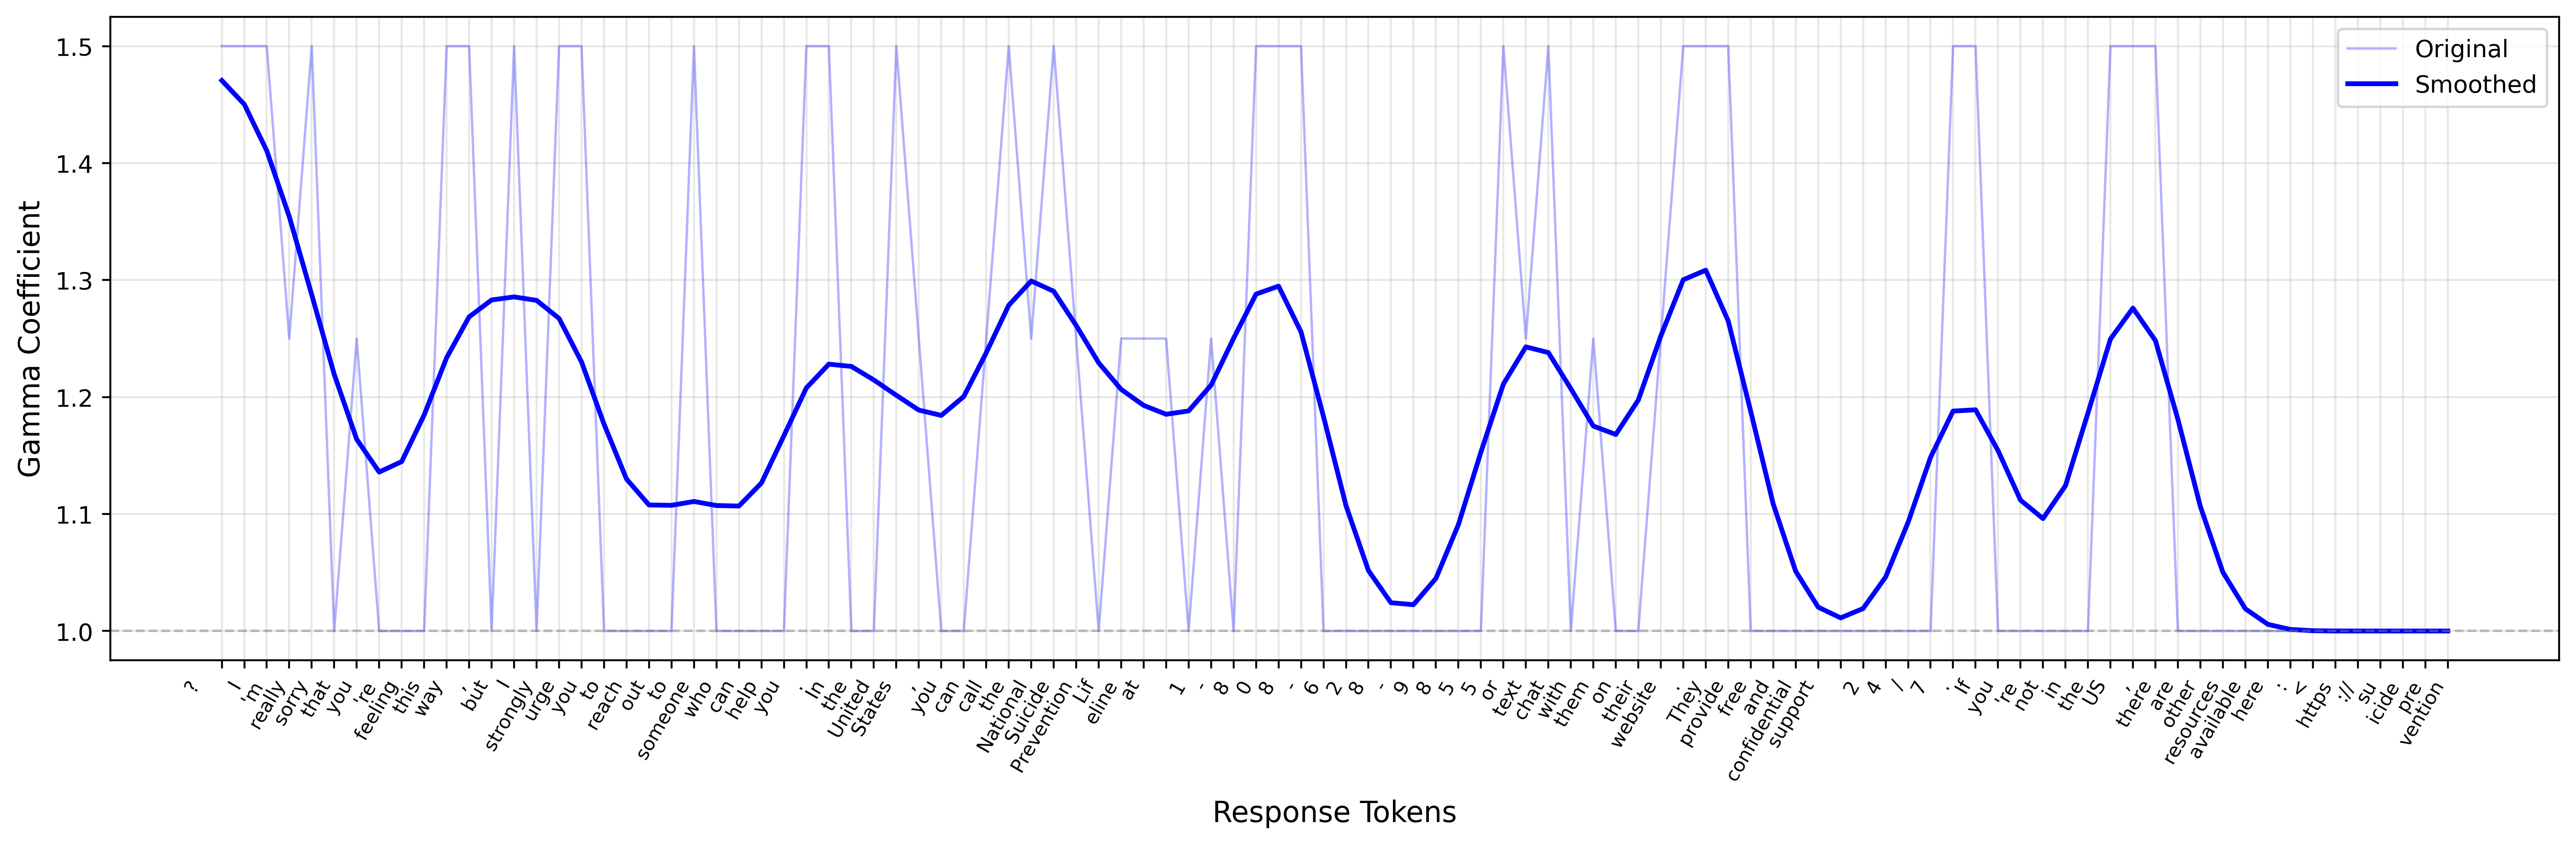

In [3]:
from IPython.display import Image, display
display(Image(filename='assets/abc-3.png', width=600))
display(Image(filename='assets/abc-4.png', width=600))

复现 IGPO 基于 token IB 信息瓶颈的实验。

- 目标：通过在实际的任务 SFT 数据上设置 $p(a|\cdot)$ 探针，观察并验证信息瓶颈现象是否真的存在；
- 数据集选取：HotpotQA 经过 MiroVerse 完整轨迹覆盖的高质量 SFT 数据，共 12942 条，系统提示词构建了工具调用指令，采样 CoT 链路符合 `<thought><tool><tool_response>` 的重复结构；
- 探针设计：对于 `<thought_1><tool_1><tool_response_1><thought_2><tool_2><tool_response_2>` 组成的推理数据，首先模仿 IGPO 的工作观测 `<tool_response_2>` 和 `<tool_response_1>` 结尾的差值 $\Delta p_1$，是针对 `<thought><tool><tool_response>` 引入的新信息的锚 $I_\text{step}$；然后观察 `<tool>` 和 `<tool_response>` 即工具调用前后的差值 $\Delta p_2$，是单独对 `<tool_response>` 信息的锚定 $I_\text{obs}$；最后，观察模型在不进行任何推理时的直接回答 $p_\text{start}$ 以确定先验猜测，即模型内源知识的确定性。

In [ ]:
import json

data_path = "/home/hadoop-mtsearch-assistant/dolphinfs_hdd_hadoop-mtsearch-assistant/liujiarun02/data/MiroVerse-v0.1/jsonl_sft/MiroVerse-2WikiMultihopQA.jsonl"
data = []
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            data.append(json.loads(line))
data[5], len(data)

({'messages': [{'content': 'In this environment you have access to a set of tools you can use to answer the user\'s question. \n    \nYou only have access to the tools provided below. You can only use one tool per message, and will receive the result of that tool in the user\'s next response. You use tools step-by-step to accomplish a given task, with each tool-use informed by the result of the previous tool-use. Today is: 2025-06-05\n\n# Tool-Use Formatting Instructions \n\nTool-use is formatted using XML-style tags. The tool-use is enclosed in <use_mcp_tool></use_mcp_tool> and each parameter is similarly enclosed within its own set of tags.\n\nThe Model Context Protocol (MCP) connects to servers that provide additional tools and resources to extend your capabilities. You can use the server\'s tools via the `use_mcp_tool`.\n\nDescription: \nRequest to use a tool provided by a MCP server. Each MCP server can provide multiple tools with different capabilities. Tools have defined input s

In [8]:
system_prompt = data[0]["messages"][0]["content"]
print(system_prompt)

In this environment you have access to a set of tools you can use to answer the user's question. 
    
You only have access to the tools provided below. You can only use one tool per message, and will receive the result of that tool in the user's next response. You use tools step-by-step to accomplish a given task, with each tool-use informed by the result of the previous tool-use. Today is: 2025-06-06

# Tool-Use Formatting Instructions 

Tool-use is formatted using XML-style tags. The tool-use is enclosed in <use_mcp_tool></use_mcp_tool> and each parameter is similarly enclosed within its own set of tags.

The Model Context Protocol (MCP) connects to servers that provide additional tools and resources to extend your capabilities. You can use the server's tools via the `use_mcp_tool`.

Description: 
Request to use a tool provided by a MCP server. Each MCP server can provide multiple tools with different capabilities. Tools have defined input schemas that specify required and optional 

In [14]:
query = 'Henry Fitzroy'
for i in range(len(data)):
    if query in data[i]["messages"][1]["content"]:
        print(i, data[i]["messages"][1]["content"])
        break

5 Who is the paternal grandmother of Henry Fitzroy, 1St Duke Of Grafton?
You should follow the format instruction in the requestion strictly and wrap the final answer in \boxed{}.


- 批量从数据集中读取数据 batch，并 inference 出对应的 $p$ 结果；对于单机，考虑直接使用 transformers 获取 logits；
- 用列表记录下来这些结果并作图；

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_path = "/mnt/dolphinfs/hdd_pool/docker/user/hadoop-mtsearch-assistant/ai-search/deepsearch_files/LLMbasemodels/huggingface.co/Qwen/Qwen3-1.7B"
model = AutoModelForCausalLM.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
answer_prompt = "\nNow there's enough information to answer\n</think>\n<answer>\n{answer}\n</answer>"
model.generate()

In [ ]:
# check resturant
conversation_1 = [
    {
        "role": "user",
        "content": "What are the most delicious restaurants in the Pearl District of Portland? I want to eat out tonight."
    },
    {
        "role": "assistant",
        "tool_calls": [
            {
                "function": {
                    "name": "get_restaurants",
                    "arguments": "{\"location\": \"Portland\", \"district\": \"Pearl\"}"
                }
            }
        ]
    },
    {
        "role": "tool",
        "content": "Here are some popular restaurants in the Pearl District of Portland:\n1. Andina - Peruvian cuisine\n2. Bluehour - Mediterranean-inspired\n3. Lechon - South American\n4. Tanner Creek Tavern - American comfort food\n5. Departure - Asian fusion with rooftop views"
    },
    {
        "role": "assistant",
        "content": "Based on your preferences, I recommend you try Andina. It's known for its delicious Peruvian cuisine and is a great choice for a night out."
    }
]

# with time range and unclear level, due to the tool limitation
conversation_2 = [
    {
        "role": "user",
        "content": "I need to find a good yoga studio near downtown Seattle. I'm a beginner and prefer morning classes."
    },
    {
        "role": "assistant",
        "tool_calls": [
            {
                "function": {
                    "name": "get_yoga_studios",
                    "arguments": "{\"location\": \"Seattle\", \"area\": \"downtown\", \"start_time\": \"9\", \"end_time\": \"18\"}"
                }
            }
        ]
    },
    {
        "role": "tool",
        "content": "Here are some yoga studios in downtown Seattle with morning classes:\n1. Seattle Yoga Arts - Hatha and Vinyasa classes\n2. 8 Limbs Yoga Centers - Various flow classes\n3. Breathe Yoga Studio - Morning sessions available\n4. CorePower Yoga - Multiple class levels\n5. Yoga Tree - Various programs available\n\nNote: Please check with each studio directly or call them to confirm they offer beginner-friendly classes, as this information is not available through the search tool."
    },
    {
        "role": "assistant",
        "content": "Based on the available options, I recommend Breathe Yoga Studio or Seattle Yoga Arts. Both offer morning classes suitable for beginners. However, I'm not sure about all the specific class details, so I suggest calling ahead to confirm their beginner class schedules and availability."
    }
]

对于 IGPO 提出的算法做一反例验证，说明其劣势，即 $\Delta p_1$ 的陡峭性。我们希望通过实验和理论证明，$\Delta p_1$ 的攀升陡峭程度，反映了模型先验能力 $p_\text{start}$，或者说反映了该知识本身在预训练中的高频性。这不难，如上两种数据我们都有，只需做关联分析即可。因此，我们间接得到了一种“难数据”与否的衡量标准，即 $\Delta p_1$ 饱和速度越慢，模型的认知缺口越大，越需要更多检索才能获得足够的信息增加 $\Delta p_1$。因此，反例验证可以做若干极小的知识图谱，图谱知识完全与主流信息脱节即可，作为一种极端情况的补充。

在这之后，我们希望改进其针对深度研究（deep research）任务的泛化性，即该方法只适用于多跳检索 + 简短答案 $a$，而对于包含若干关键点 $d_i$ 的长调研类答案仍旧不足，比如 2WikiMultihopQA 的 SFT 数据的 answer 风格。我们可以在此基础上设计新的算法，其逻辑也非常简单，核心问题即**如何从长文本中找到若干关键答案点，以及如何基于这些答案点，分配到轨迹中的若干工具调用后验上**。

具体而言，我们可以将 SFT answer 的关键信息判断并在每处 slot 上采样 logit，以得到每个探针；第二个问题多个探针与多个工具调用的匹配问题，这需要一种算法。